# Custom Latitude Distributions

This notebook shows how to define a custom starspot latitude distribution by
subclassing `LatitudeDistributionFunction` and how it propagates through the
`spotgp` pipeline.

**Two roles of the latitude distribution:**

| Component | Role |
|---|---|
| `AnalyticKernel` | PDF weights the latitude integral $\int p(\phi)\,K(\phi,\tau)\,d\phi$ |
| `LightcurveModel.from_spot_model` | `lat_range` sets the uniform sampling bounds for spot placement |

**Sections**
1. Default uniform distribution
2. Equatorial band — narrow `lat_range`
3. Gaussian-weighted distribution — custom PDF over latitude
4. Polar band — spots at high latitudes
5. Kernel and lightcurve comparison across all distributions

In [4]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from src_jax import (
    LatitudeDistributionFunction,
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    LightcurveModel,
    AnalyticKernel,
)

label_fs = 18
np.random.seed(42)

# Shared model components reused throughout
_envelope   = TrapezoidSymmetricEnvelope(lspot=15.0, tau_spot=5.0)
_visibility = VisibilityFunction(peq=10.0, kappa=0.3, inc=np.pi / 3)

---
## 1. Default uniform distribution

When no `latitude_distribution` is supplied to `SpotEvolutionModel`, a
`LatitudeDistributionFunction()` is used — uniform over
$[-\pi/2,\, \pi/2]$ (all latitudes with equal weight).

In [2]:
lat_uniform = LatitudeDistributionFunction()
print(lat_uniform)
print("lat_range :", lat_uniform.lat_range)
print("p(0)      :", lat_uniform(0.0))
print("p(pi/4)   :", lat_uniform(np.pi / 4))

model_uniform = SpotEvolutionModel(
    envelope=_envelope,
    visibility=_visibility,
    sigma_k=0.01,
    # latitude_distribution defaults to LatitudeDistributionFunction()
)

LatitudeDistributionFunction(lat_range=[-1.571, 1.571])
lat_range : (-1.5707963267948966, 1.5707963267948966)
p(0)      : 1.0
p(pi/4)   : 1.0


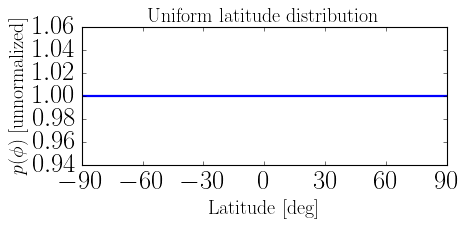

In [5]:
phi = np.linspace(-np.pi / 2, np.pi / 2, 300)
pdf_vals = np.array([lat_uniform(p) for p in phi])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.rad2deg(phi), pdf_vals, lw=2)
ax.set_xlabel("Latitude [deg]", fontsize=label_fs)
ax.set_ylabel(r"$p(\phi)$ [unnormalized]", fontsize=label_fs)
ax.set_title("Uniform latitude distribution", fontsize=label_fs)
ax.set_xlim(-90, 90)
ax.set_xticks(np.arange(-90, 91, 30))
fig.tight_layout()
plt.show()

---
## 2. Equatorial band

Restrict spots to low latitudes by overriding `lat_range`.  The PDF itself
remains uniform within the narrower range.

In [6]:
class EquatorialBand(LatitudeDistributionFunction):
    """Uniform distribution confined to |phi| < max_lat."""

    def __init__(self, max_lat_deg: float = 30.0):
        self._max_lat = float(np.deg2rad(max_lat_deg))

    @property
    def lat_range(self) -> tuple:
        return (-self._max_lat, self._max_lat)

    def __call__(self, phi: float) -> float:
        return 1.0


lat_equatorial = EquatorialBand(max_lat_deg=30.0)
print(lat_equatorial)
print("lat_range :", tuple(np.rad2deg(lat_equatorial.lat_range).round(1)), "deg")

model_equatorial = SpotEvolutionModel(
    envelope=_envelope,
    visibility=_visibility,
    sigma_k=0.01,
    latitude_distribution=lat_equatorial,
)

EquatorialBand(lat_range=[-0.524, 0.524])
lat_range : (np.float64(-30.0), np.float64(30.0)) deg


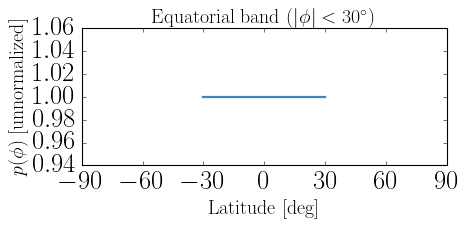

In [9]:
phi_eq  = np.linspace(*lat_equatorial.lat_range, 300)
pdf_eq  = np.array([lat_equatorial(p) for p in phi_eq])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.rad2deg(phi_eq), pdf_eq, lw=2, color="steelblue")
ax.set_xlabel("Latitude [deg]", fontsize=label_fs)
ax.set_ylabel(r"$p(\phi)$ [unnormalized]", fontsize=label_fs)
ax.set_title(r"Equatorial band ($|\phi| < 30^\circ$)", fontsize=label_fs)
ax.set_xlim(-90, 90)
ax.set_xticks(np.arange(-90, 91, 30))
fig.tight_layout()
plt.show()

---
## 3. Gaussian-weighted distribution

A Gaussian PDF smoothly down-weights high latitudes rather than cutting them
off sharply.  Both `lat_range` and `__call__` are overridden.

In [10]:
class GaussianLatitude(LatitudeDistributionFunction):
    """
    Gaussian PDF centred at `center` with standard deviation `sigma`.

    Spots can emerge anywhere within ±3σ of the center, but are weighted
    toward the center of the distribution.
    """

    def __init__(self, sigma_deg: float = 20.0, center_deg: float = 0.0):
        self._sigma  = float(np.deg2rad(sigma_deg))
        self._center = float(np.deg2rad(center_deg))

    @property
    def lat_range(self) -> tuple:
        return (self._center - 3 * self._sigma,
                self._center + 3 * self._sigma)

    def __call__(self, phi: float) -> float:
        return float(np.exp(-0.5 * ((phi - self._center) / self._sigma) ** 2))


lat_gauss = GaussianLatitude(sigma_deg=20.0)
print(lat_gauss)
print("lat_range :", tuple(np.rad2deg(lat_gauss.lat_range).round(1)), "deg")
print("p(0)      :", lat_gauss(0.0))
print("p(30 deg) :", lat_gauss(np.deg2rad(30.0)))

model_gauss = SpotEvolutionModel(
    envelope=_envelope,
    visibility=_visibility,
    sigma_k=0.01,
    latitude_distribution=lat_gauss,
)

GaussianLatitude(lat_range=[-1.047, 1.047])
lat_range : (np.float64(-60.0), np.float64(60.0)) deg
p(0)      : 1.0
p(30 deg) : 0.32465246735834974


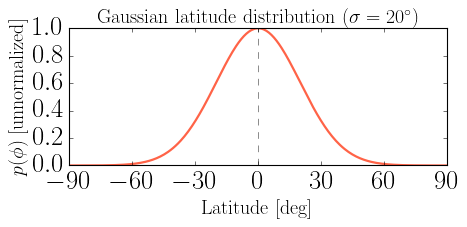

In [11]:
phi_g   = np.linspace(-np.pi / 2, np.pi / 2, 300)
pdf_g   = np.array([lat_gauss(p) for p in phi_g])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.rad2deg(phi_g), pdf_g, lw=2, color="tomato")
ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Latitude [deg]", fontsize=label_fs)
ax.set_ylabel(r"$p(\phi)$ [unnormalized]", fontsize=label_fs)
ax.set_title(r"Gaussian latitude distribution ($\sigma = 20^\circ$)", fontsize=label_fs)
ax.set_xlim(-90, 90)
ax.set_xticks(np.arange(-90, 91, 30))
fig.tight_layout()
plt.show()

---
## 4. Polar band

Spots confined to high latitudes (like solar polar faculae).  Implemented
as two symmetric bands, one at each pole.

In [12]:
class PolarBand(LatitudeDistributionFunction):
    """
    Two symmetric bands near the poles: |phi| in [min_lat, pi/2].
    """

    def __init__(self, min_lat_deg: float = 60.0):
        self._min_lat = float(np.deg2rad(min_lat_deg))

    @property
    def lat_range(self) -> tuple:
        # Full range so spots can land at either pole
        return (-np.pi / 2, np.pi / 2)

    def __call__(self, phi: float) -> float:
        # Non-zero weight only at high latitudes
        return 1.0 if abs(phi) >= self._min_lat else 0.0


lat_polar = PolarBand(min_lat_deg=60.0)
print(lat_polar)
print("p(0)      :", lat_polar(0.0))
print("p(70 deg) :", lat_polar(np.deg2rad(70.0)))

model_polar = SpotEvolutionModel(
    envelope=_envelope,
    visibility=_visibility,
    sigma_k=0.01,
    latitude_distribution=lat_polar,
)

PolarBand(lat_range=[-1.571, 1.571])
p(0)      : 0.0
p(70 deg) : 1.0


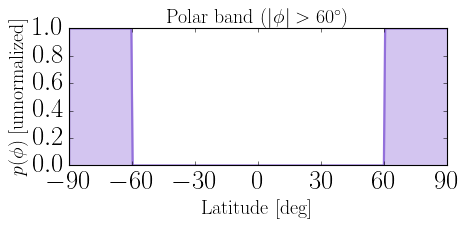

In [13]:
phi_p   = np.linspace(-np.pi / 2, np.pi / 2, 300)
pdf_p   = np.array([lat_polar(p) for p in phi_p])

fig, ax = plt.subplots(figsize=(6, 3))
ax.fill_between(np.rad2deg(phi_p), pdf_p, alpha=0.4, color="mediumpurple")
ax.plot(np.rad2deg(phi_p), pdf_p, lw=2, color="mediumpurple")
ax.set_xlabel("Latitude [deg]", fontsize=label_fs)
ax.set_ylabel(r"$p(\phi)$ [unnormalized]", fontsize=label_fs)
ax.set_title(r"Polar band ($|\phi| > 60^\circ$)", fontsize=label_fs)
ax.set_xlim(-90, 90)
ax.set_xticks(np.arange(-90, 91, 30))
fig.tight_layout()
plt.show()

---
## 5. Kernel and lightcurve comparison

### 5a. GP kernel shapes

The latitude distribution modifies which latitudes contribute to the
kernel integral.  Spots at different latitudes rotate at different speeds
(differential rotation), so the kernel shape — and in particular how
quickly the periodic signal dephases — depends on the latitude distribution.

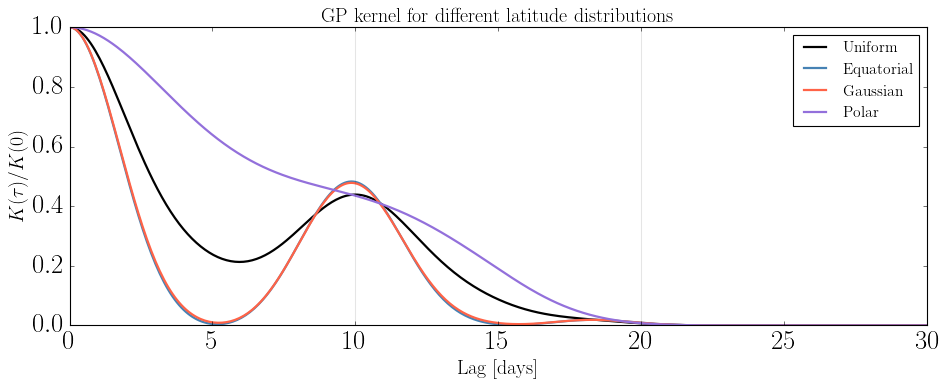

In [14]:
models = {
    "Uniform":    model_uniform,
    "Equatorial": model_equatorial,
    "Gaussian":   model_gauss,
    "Polar":      model_polar,
}
colors = {
    "Uniform":    "k",
    "Equatorial": "steelblue",
    "Gaussian":   "tomato",
    "Polar":      "mediumpurple",
}

lag = np.linspace(0, 3 * _visibility.peq, 400)
kernels = {}
for name, mdl in models.items():
    ak = AnalyticKernel(mdl)
    K  = ak.kernel(lag)
    kernels[name] = K

fig, ax = plt.subplots(figsize=(12, 5))
for name, K in kernels.items():
    ax.plot(lag, K / K[0], label=name, color=colors[name], lw=2)
for n in range(1, int(lag[-1] / _visibility.peq) + 1):
    ax.axvline(n * _visibility.peq, color="k", alpha=0.1, lw=1)
ax.set_xlabel("Lag [days]", fontsize=label_fs)
ax.set_ylabel(r"$K(\tau) / K(0)$", fontsize=label_fs)
ax.set_title("GP kernel for different latitude distributions", fontsize=label_fs)
ax.legend(fontsize=14)
ax.set_xlim(lag[0], lag[-1])
fig.tight_layout()
plt.show()

### 5b. Lightcurve comparison

`LightcurveModel.from_spot_model` uses `lat_range` from the latitude
distribution to set the bounds for **uniform** spot placement.  The PDF
shape (if non-uniform) affects only the kernel integration in
`AnalyticKernel`; the forward simulation always samples uniformly within
`lat_range`.  For a non-uniform forward simulation you would need to
implement rejection sampling from the PDF.

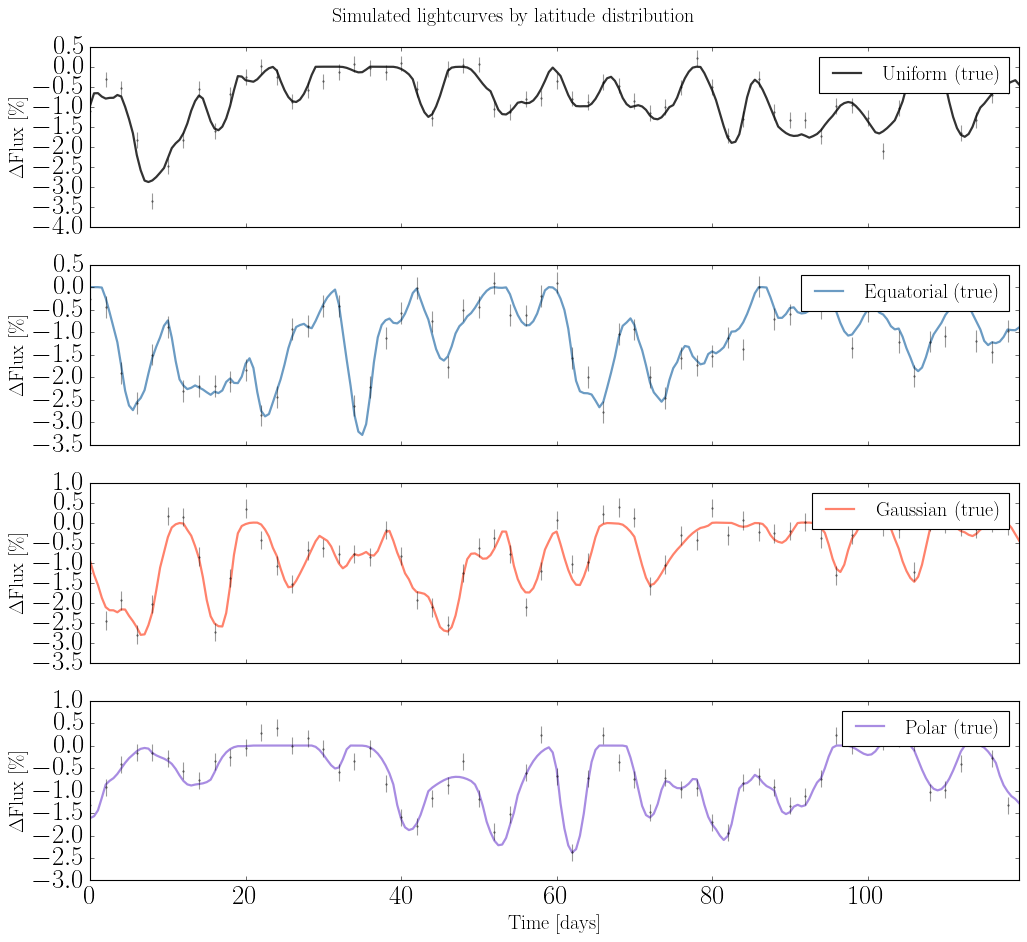

In [17]:
fig, axes = plt.subplots(len(models), 1, figsize=(13, 3 * len(models)),
                         sharex=True)

for ax, (name, mdl) in zip(axes, models.items()):
    lc = LightcurveModel.from_spot_model(
        mdl, nspot=30, tsim=120, tsamp=0.5,
    )
    sigma_n  = 0.3 * np.std(lc.flux)
    flux_obs = lc.flux + np.random.normal(0, sigma_n, lc.flux.shape)

    ax.plot(lc.t, (lc.flux - 1) * 100, color=colors[name], lw=2,
            alpha=0.8, label=f"{name} (true)")
    ax.errorbar(lc.t[::4], (flux_obs[::4] - 1) * 100,
                yerr=sigma_n * 100,
                fmt=".k", ms=3, capsize=0, alpha=0.4)
    ax.set_ylabel(r"$\Delta$Flux [\%]", fontsize=label_fs)
    ax.set_xlim(lc.t[0], lc.t[-1])
    ax.legend(fontsize=label_fs, loc="upper right")

axes[-1].set_xlabel("Time [days]", fontsize=label_fs)
fig.suptitle("Simulated lightcurves by latitude distribution", fontsize=label_fs)
fig.tight_layout()
plt.show()

### 5c. Spot latitude placement

The scatter plot below shows which latitudes are drawn for each model.
Latitudes outside `lat_range` are never placed; within `lat_range` the
sampling is always uniform (regardless of the PDF shape).

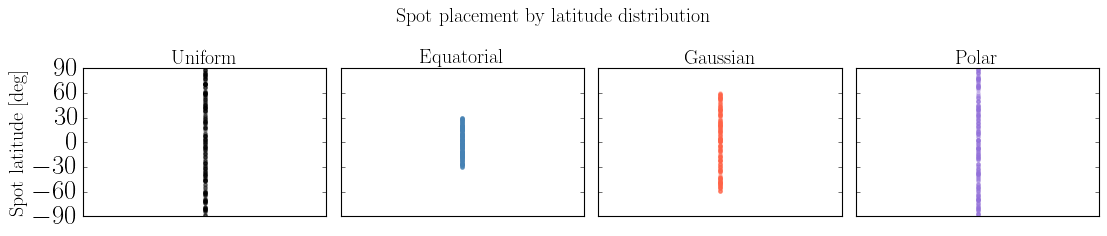

In [18]:
np.random.seed(7)
nspot = 200
fig, axes = plt.subplots(1, len(models), figsize=(14, 3), sharey=True)

for ax, (name, mdl) in zip(axes, models.items()):
    lc = LightcurveModel.from_spot_model(
        mdl, nspot=nspot, tsim=200, tsamp=1.0,
    )
    lats_deg = np.rad2deg(lc.lat)
    ax.scatter(np.zeros(nspot), lats_deg, alpha=0.3, s=10, color=colors[name])
    ax.set_title(name, fontsize=label_fs)
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-90, 90)
    ax.set_yticks(np.arange(-90, 91, 30))
    ax.set_xticks([])

axes[0].set_ylabel("Spot latitude [deg]", fontsize=label_fs)
fig.suptitle("Spot placement by latitude distribution", fontsize=label_fs)
fig.tight_layout()
plt.show()